#Decision Tree Classifier (Alteration on Baseline Study)
> In this final notebook, we aim to customize/adapt the best model found in the study we used as our baseline

> We aim to attempt to replicate the study's results, then try to improve upon them

In [724]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, LearningCurveDisplay
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold, RFE
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV

## Data cleaning and target encoding

In [725]:
data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Molecules_Toxicity_Classification.xlsx")
data.drop("Unnamed: 0", inplace=True, axis=1)
encoder = LabelEncoder()
data["Class"] = encoder.fit_transform(data["Class"])

In [726]:
X = data.drop("Class", axis=1)
y = data["Class"]

## Splitting the data
> We went for a smaller 9% test split to ensure maximum data for training while still keeping the testing set meaningful

In [727]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.09, shuffle=True, random_state=2)

## Using Highest Importance Features From Study
> The aim of the study was to identify the features that are most important for classification of molecules.
> We decided to use that to our advantage and use these features as the starting point for our model

In [728]:
cols = ['MDEC-23', 'MATS2v', 'ATSC8s', 'VE3_Dt', 'CrippenMR',
        'SpMax7_Bhe', 'SpMin1_Bhs', 'C1SP2', 'GATS8e', 'GATS8s',
        'SpMax5_Bhv', 'VE3_Dzi', 'VPC-4']
X_train = X_train[cols]
X_test = X_test[cols]

In [729]:
estimator = DecisionTreeClassifier(
    max_depth=None,
    max_features=13,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=0
)

In [730]:
cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

## Adjusting class weights for smaller dataset
> Our dataset is smaller than the dataset used in the study by around 12 exapmles. Although seems like a small number, it makes a noticable difference when the dataset is this small.

> This decrease in size means that the model will have less chances to look at positive examples, meaning that we would need a higher class weight for positive class

> To find the optimal class weight, we perform a grid search on the class weights

In [731]:
grid_search = GridSearchCV(estimator, param_grid={"class_weight":[{1:1.53, 0:0.74}, {1:1.6, 0:0.74}, {1:1.75, 0:0.74}, {1:1.8, 0:0.74}, {1:1.53, 0:0.72}, {1:1.6, 0:0.7}, {1:1.75, 0:0.68}, {1:1.8, 0:0.65}]}, cv=cv, scoring='accuracy')

In [732]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=8, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(max_features=13,
                                              min_samples_split=5,
                                              random_state=0),
             param_grid={'class_weight': [{0: 0.74, 1: 1.53}, {0: 0.74, 1: 1.6},
                                          {0: 0.74, 1: 1.75}, {0: 0.74, 1: 1.8},
                                          {0: 0.72, 1: 1.53}, {0: 0.7, 1: 1.6},
                                          {0: 0.68, 1: 1.75},
                                          {0: 0.65, 1: 1.8}]},
             scoring='accuracy')

## CV Results close to study

> Our CV results were very close to those of the study (79%).

> We theorize that the difference is due to the 12 missing examples which might have contributed meaningful information to the model

In [733]:
grid_search.best_score_

np.float64(0.7708333333333334)

## Different Weights

> As we can see, our grid search revealed

In [734]:
grid_search.best_params_

{'class_weight': {1: 1.8, 0: 0.65}}

## Relatively Consistant CV Results

> Our cv results are all relatively consistent, being in the mid to high 70 range

In [735]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004827,0.000496,0.002404,0.000292,"{1: 1.53, 0: 0.74}","{'class_weight': {1: 1.53, 0: 0.74}}",0.833333,0.888889,0.722222,0.777778,0.722222,0.722222,0.722222,0.555556,0.743056,0.091866,6
1,0.004928,0.000579,0.002565,0.000277,"{1: 1.6, 0: 0.74}","{'class_weight': {1: 1.6, 0: 0.74}}",0.833333,0.888889,0.722222,0.777778,0.777778,0.722222,0.666667,0.555556,0.743056,0.095974,6
2,0.004949,0.000892,0.002363,0.000186,"{1: 1.75, 0: 0.74}","{'class_weight': {1: 1.75, 0: 0.74}}",0.833333,0.888889,0.722222,0.777778,0.722222,0.722222,0.666667,0.611111,0.743056,0.083043,6
3,0.004504,0.000498,0.002275,0.000420,"{1: 1.8, 0: 0.74}","{'class_weight': {1: 1.8, 0: 0.74}}",0.833333,0.888889,0.722222,0.777778,0.777778,0.722222,0.777778,0.611111,0.763889,0.077330,2
4,0.004531,0.000467,0.002356,0.000482,"{1: 1.53, 0: 0.72}","{'class_weight': {1: 1.53, 0: 0.72}}",0.833333,0.888889,0.722222,0.777778,0.722222,0.722222,0.833333,0.555556,0.756944,0.095974,3
5,0.005710,0.000930,0.002984,0.000704,"{1: 1.6, 0: 0.7}","{'class_weight': {1: 1.6, 0: 0.7}}",0.833333,0.888889,0.722222,0.777778,0.777778,0.722222,0.722222,0.611111,0.756944,0.078260,3
6,0.004525,0.000599,0.002132,0.000101,"{1: 1.75, 0: 0.68}","{'class_weight': {1: 1.75, 0: 0.68}}",0.833333,0.888889,0.722222,0.777778,0.722222,0.722222,0.722222,0.611111,0.750000,0.078567,5
7,0.004456,0.000347,0.002195,0.000144,"{1: 1.8, 0: 0.65}","{'class_weight': {1: 1.8, 0: 0.65}}",0.833333,0.888889,0.722222,0.777778,0.777778,0.722222,0.722222,0.722222,0.770833,0.058515,1


In [736]:
clf = grid_search.best_estimator_

In [737]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.65, 1: 1.8}, max_features=13,
                       min_samples_split=5, random_state=0)

In [738]:
y_pred = clf.predict(X_test)

## Testing accuracy and statistics
> We were quite happy with the final testing accuracy of 93%. We aknowledge that the recall is slightly low, however, this was our best result so far.

> We also want to note that with the test sets being this small, it really is hard to gauge whether testing accuarcy is representative of generalizability.

In [739]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.83      1.00      0.91         5

    accuracy                           0.93        15
   macro avg       0.92      0.95      0.93        15
weighted avg       0.94      0.93      0.93        15



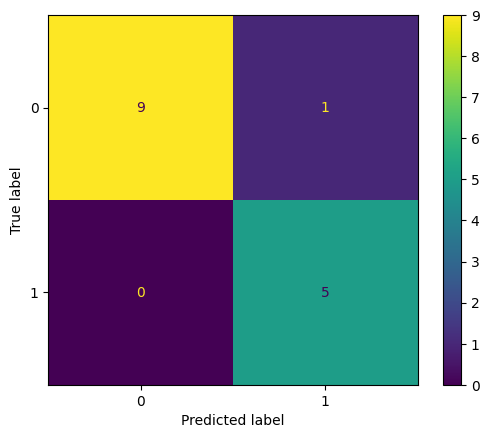

In [740]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

## Overfitting
> We realize that the model might be overfitting, however, as discussed in class, we chose to go with the model that gave the highest testing accuracy

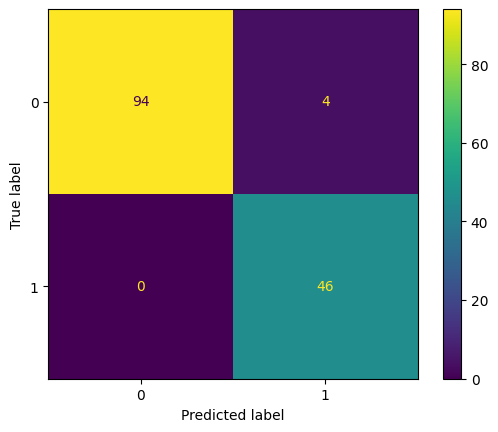

In [741]:
ConfusionMatrixDisplay(confusion_matrix(y_train, clf.predict(X_train))).plot()

In [742]:
"""
Takes the X of the testing data, applies necessary transformations, and returns the predictions vector of it
"""
def get_predictions(test_data):
  test_data.drop("Unnamed: 0", inplace=True, axis=1)
  test_data = test_data[cols]
  return clf.predict(test_data)